<a href="https://colab.research.google.com/github/dinaglamshowroom/projet-data_oc/blob/main/Projet_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Projet 9 – Prédire la demande d’électricité**

# Introduction

## Objectif

La consommation d’électricité est soumise à de nombreuses fluctuations, notamment dues à la saisonnalité et aux conditions climatiques. Dans ce projet, nous avons pour objectif de :

* Corriger l’effet température sur la consommation,

* Désaisonnaliser la série,

* Prédire la consommation pour une période future (12 mois) à l’aide de Holt-Winters et SARIMA.

# Chargement et préparation des données

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from collections import defaultdict
import os, glob
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy import stats
from sklearn import datasets
import zipfile
import os
from google.colab import files
import scipy.stats as st
import os, glob
from google.colab import files
from statsmodels.formula.api import ols
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:

os.makedirs("plots", exist_ok=True)

_plot_counter = 1

_old_show = plt.show

def _new_show(*args, **kwargs):
    global _plot_counter
    nom = f"plots/plot_{_plot_counter:03d}.png"
    plt.savefig(nom, dpi=300, bbox_inches="tight")
    _plot_counter += 1
    _old_show(*args, **kwargs)

plt.show = _new_show

In [4]:
DATA_DIR = "/content/drive/MyDrive/Projet_9"
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print("Fichiers CSV trouvés :")
for f in csv_files:
    print(f)

Fichiers CSV trouvés :
/content/drive/MyDrive/Projet_9/data_conso.csv
/content/drive/MyDrive/Projet_9/df_merged.csv
/content/drive/MyDrive/Projet_9/df_dju.csv


In [5]:
DATA_DIR = "/content/drive/MyDrive/Projet_9"
xlsx_files = glob.glob(os.path.join(DATA_DIR, "*.xlsx"))

print("Fichiers XLSX trouvés :")
for f in xlsx_files:
    print(f)

Fichiers XLSX trouvés :
/content/drive/MyDrive/Projet_9/calcul_DJU_15_12_2025.xlsx


In [6]:
dfs = {f.split("/")[-1]: pd.read_csv(f) for f in csv_files}

for name, df in dfs.items():
    print(f"{name}: {df.shape}")

data_conso.csv: (3288, 13)
df_merged.csv: (108, 7)
df_dju.csv: (120, 6)


In [7]:
df_data_conso = dfs["data_conso.csv"]

In [8]:
dfs = {f.split("/")[-1]: pd.read_excel(f) for f in xlsx_files}

for name, df in dfs.items():
    print(f"{name}: {df.shape}")

calcul_DJU_15_12_2025.xlsx: (28, 14)


In [9]:
df_dju = dfs["calcul_DJU_15_12_2025.xlsx"]

In [10]:
df_data_conso.head()

,date,consommation,prevision_j1,prevision_j,fioul,charbon,gaz,nucleaire,eolien,solaire,hydraulique,pompage,bioenergies
0,2012-01-01,2471592.0,4901850.0,4841050.0,23649.0,758.0,181778.0,2153346.0,188459.0,6255.0,367472.0,-86821.0,33411.0
1,2012-01-02,2912815.0,5796450.0,5739050.0,23598.0,378.0,194404.0,2557111.0,147353.0,4267.0,412364.0,-50571.0,31219.0
2,2012-01-03,3252581.0,6349550.0,6392550.0,24700.0,205.0,193376.0,2794380.0,228569.0,6768.0,484559.0,-48850.0,31888.0
3,2012-01-04,3265403.0,6455450.0,6430900.0,26208.0,7.0,178234.0,2767347.0,203392.0,8655.0,490193.0,-42190.0,32737.0
4,2012-01-05,3319555.0,6410150.0,6484500.0,25809.0,16.0,203859.0,2712466.0,249564.0,3207.0,516675.0,-40085.0,32991.0


In [11]:
df_daily = df_data_conso.copy()

In [12]:
import pandas as pd


# 2. Conversion de la colonne 'date' en format datetime
df_daily['date'] = pd.to_datetime(df_daily['date'])

# 3. Mise de la date comme index
df_daily.set_index('date', inplace=True)

# 4. Agrégation mensuelle par somme
df_monthly = df_daily.resample('M').sum()

# 5. Ajout des colonnes 'year' et 'month'
df_monthly['year'] = df_monthly.index.year
df_monthly['month'] = df_monthly.index.month

# 6. Réduction aux colonnes utiles : consommation, year, month
df_monthly_reduced = df_monthly[['consommation', 'year', 'month']].copy()


In [13]:
df_monthly.head()

,consommation,prevision_j1,prevision_j,fioul,charbon,gaz,nucleaire,eolien,solaire,hydraulique,pompage,bioenergies,year,month
date,,,,,,,,,,,,,,
2012-01-31,101573076.0,201985150.0,201244900.0,893223.0,1537770.0,8150964.0,85553029.0,3170579.0,233044.0,13372457.0,-1222987.0,1039213.0,2012,1
2012-02-29,108364070.0,217363100.0,216323300.0,2070743.0,5111869.0,9966798.0,77305538.0,2242160.0,404651.0,10405047.0,-835944.0,924169.0,2012,2
2012-03-31,85891077.0,170930500.0,170495850.0,875593.0,2921514.0,6575791.0,75117981.0,1950245.0,665576.0,7740614.0,-876794.0,1080601.0,2012,3
2012-04-30,79899382.0,157598200.0,158495650.0,705657.0,3298460.0,2813866.0,66152813.0,3137120.0,614459.0,10521234.0,-1027837.0,820778.0,2012,4
2012-05-31,70077667.0,139979450.0,139473550.0,526000.0,1706754.0,1234807.0,58064275.0,1944665.0,851728.0,15256472.0,-1293309.0,943855.0,2012,5


In [14]:
df_monthly_reduced.index = pd.to_datetime(df_monthly_reduced.index)


In [15]:
df_monthly_reduced.isna().sum()

,0
consommation,0
year,0
month,0


In [16]:
df_monthly_reduced.isnull().sum()

,0
consommation,0
year,0
month,0


## Mise à l'echelle des données de consommation

L’unité exacte de la variable consommation fournie dans notre fichier source n’est pas précisée.

Afin de travailler avec des valeurs réalistes et comparables aux statistiques nationales, nous avons procédé à une mise à l’échelle empirique, basée sur les données officielles de consommation électrique en France.


Par exemple, selon les données de RTE/EDF, la consommation annuelle en France en 2012 s’est élevée à 489 500 GWh
(Source : BNSP/INSEE – Consommation d’électricité 2012 : https://www.bnsp.insee.fr/ark:/12148/bc6p071rs9g.pdf
).

Dans notre jeu de données, la somme brute de la consommation pour l’année 2012 était d’environ 973 GWh (après conversion directe des valeurs en kWh → GWh), soit un écart d’un facteur environ 2000.

In [17]:

df_monthly_reduced['conso_GWh'] = df_monthly_reduced['consommation'] / 2000


In [18]:
df_monthly_reduced.head()

,consommation,year,month,conso_GWh
date,,,,
2012-01-31,101573076.0,2012,1,50786.5380
2012-02-29,108364070.0,2012,2,54182.0350
2012-03-31,85891077.0,2012,3,42945.5385
2012-04-30,79899382.0,2012,4,39949.6910
2012-05-31,70077667.0,2012,5,35038.8335


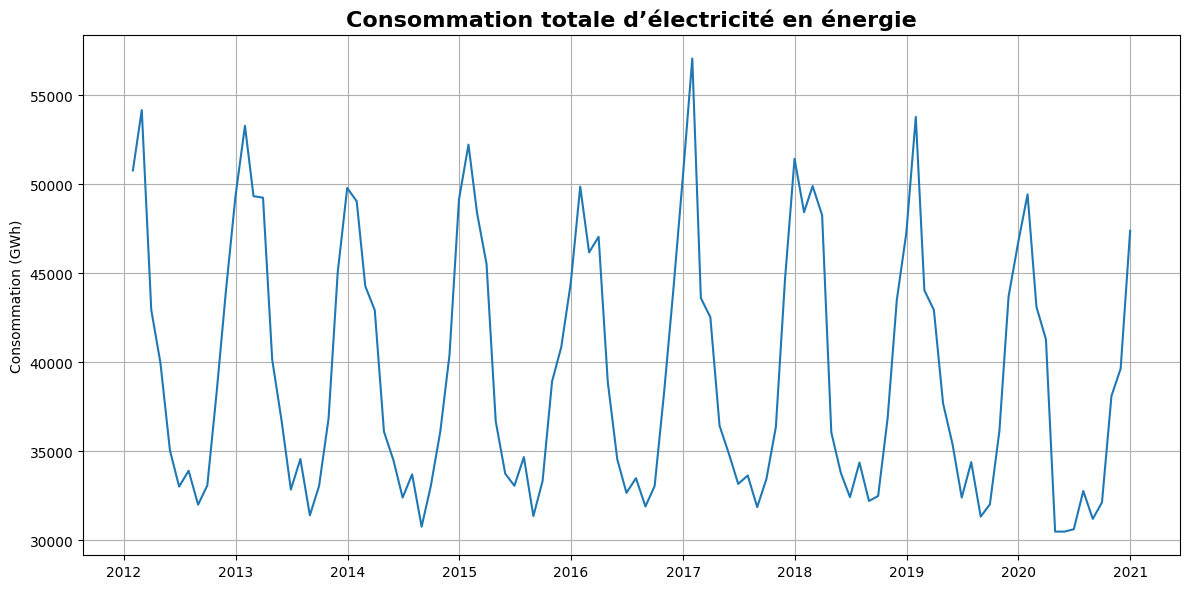

In [19]:


# Création du graphique
plt.figure(figsize=(12,6))
plt.plot(df_monthly_reduced.index, df_monthly_reduced['conso_GWh'])

# Titre et style
plt.title("Consommation totale d’électricité en énergie", fontsize=16, fontweight='bold')
plt.ylabel("Consommation (GWh)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
df1 =df_monthly_reduced.copy()

In [21]:
df1.head()

,consommation,year,month,conso_GWh
date,,,,
2012-01-31,101573076.0,2012,1,50786.5380
2012-02-29,108364070.0,2012,2,54182.0350
2012-03-31,85891077.0,2012,3,42945.5385
2012-04-30,79899382.0,2012,4,39949.6910
2012-05-31,70077667.0,2012,5,35038.8335


In [22]:
df1['date'] = pd.to_datetime(
    df1['year'].astype(str),
    format='%Y-%m',
    errors='coerce'
)


###  Analyse des mois extrêmes de consommation



L’analyse des données corrigées (en GWh) montre que :

**Le mois de janvier 2017 enregistre la consommation mensuelle la plus élevée**avec 57 081,5 GWh.
Cette valeur est cohérente avec les données climatiques : janvier 2017 a été un mois exceptionnellement froid et sec, avec des températures inférieures de 3 à 4 °C par rapport aux normales de saison.
https://meteofrance.fr/sites/meteofrance.fr/files/files/editorial/Bilan-climatique-definitif-annee2017-V2.pdf

 **avril 2020 affiche la consommation la plus faible**, avec 30 471,8 GWh.
Cette baisse s’explique par le confinement lié à la pandémie de COVID-19, qui a entraîné une forte diminution de l’activité industrielle et tertiaire, et donc une chute de la demande en électricité.

Ces deux extrêmes confirment que la consommation d’électricité est très sensible aux aléas climatiques et économiques, ce qui justifie pleinement les analyses de correction via les degrés-jours unifiés (DJU) dans la suite du projet.

In [23]:
dju=df_dju.copy()

In [24]:
dju.head()

,Export DJU 15/12/2025,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Station météo,NaN,PARIS-MONTSOURIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Usage,NaN,Chauffage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Méthode de calcul,NaN,Météo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Température de référence,NaN,18°C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
dju.columns = ['year', 'janvier', 'février', 'mars', 'avril', 'mai', 'juin',
                    'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre', 'total']

# Supprimer la colonne "total" si présente
dju = dju.drop(columns=['total'], errors='ignore')

# Transformer le tableau en format long (année + mois + dju)
dju_long = dju.melt(id_vars='year', var_name='month_name', value_name='dju')


In [26]:
dju_long.head()

,year,month_name,dju
0,NaN,janvier,NaN
1,Station météo,janvier,NaN
2,Usage,janvier,NaN
3,Méthode de calcul,janvier,NaN
4,Température de référence,janvier,NaN


In [27]:
# Dictionnaire de correspondance des mois (français → numérique)
mois_mapping = {
    'janvier': '01', 'février': '02', 'mars': '03', 'avril': '04',
    'mai': '05', 'juin': '06', 'juillet': '07', 'août': '08',
    'septembre': '09', 'octobre': '10', 'novembre': '11', 'décembre': '12'
}

# Appliquer la correspondance
dju_long['mois_num'] = dju_long['month_name'].map(mois_mapping)

# Créer une colonne date au format AAAA-MM
dju_long['date'] = pd.to_datetime(dju_long['year'].astype(str) + '-' + dju_long['mois_num'], format='%Y-%m', errors='coerce')


In [28]:
dju_long.isna().sum()

,0
year,48
month_name,0
dju,114
mois_num,0
date,132


In [29]:
# Dates min et max dans dju_long
print("Date min :", dju_long['date'].min())
print("Date max :", dju_long['date'].max())


Date min : 2009-01-01 00:00:00
Date max : 2025-12-01 00:00:00


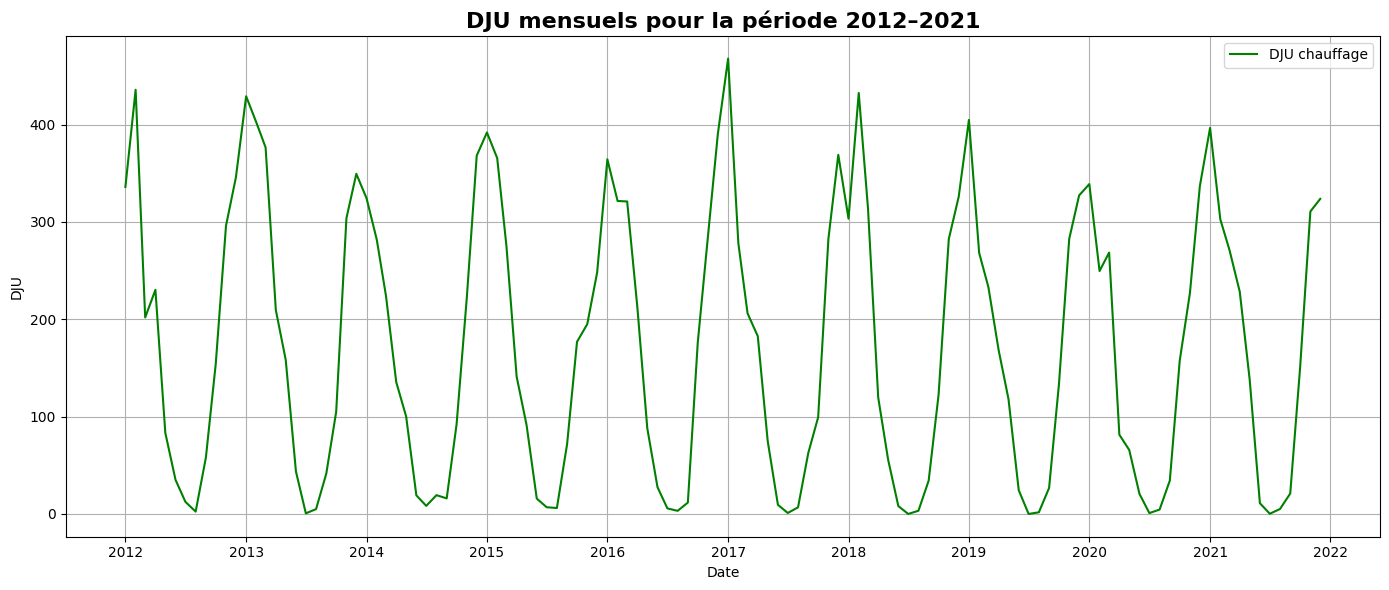

In [30]:
dju_long_clean = dju_long.dropna(subset=['date']).sort_values('date')

# 6. Filtrer la période 2012–2021
dju_filtered = dju_long_clean[(dju_long_clean['date'] >= '2012-01-01') & (dju_long_clean['date'] <= '2021-12-31')]

# 7. Tracer le graphique
plt.figure(figsize=(14,6))
plt.plot(dju_filtered['date'], dju_filtered['dju'], color='green', label='DJU chauffage')

plt.title("DJU mensuels pour la période 2012–2021", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("DJU")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()







In [31]:
dju_filtered.isna().sum()

,0
year,0
month_name,0
dju,0
mois_num,0
date,0


In [32]:
dju_filtered.isnull().sum()

,0
year,0
month_name,0
dju,0
mois_num,0
date,0


In [33]:
dju_filtered.to_csv("/content/drive/MyDrive/Projet_9/df_dju.csv")

In [34]:
# Créer une correspondance de numéro → nom du mois (comme dans les DJU)
mois_fr = ['janvier', 'février', 'mars', 'avril', 'mai', 'juin',
           'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre']

# Ajouter le nom du mois dans df_monthly_reduced
df_monthly_reduced['month_name'] = df_monthly_reduced['month'].apply(lambda x: mois_fr[x-1])


Fusion des deux dfs principales

In [35]:
# Fusion des DJU avec la consommation mensuelle
df_merged = pd.merge(df_monthly_reduced, dju_filtered, on=['year', 'month_name'], how='left')


In [36]:
df_merged.head()

,consommation,year,month,conso_GWh,month_name,dju,mois_num,date
0,101573076.0,2012,1,50786.5380,janvier,336,01,2012-01-01
1,108364070.0,2012,2,54182.0350,février,435.9,02,2012-02-01
2,85891077.0,2012,3,42945.5385,mars,201.9,03,2012-03-01
3,79899382.0,2012,4,39949.6910,avril,230.3,04,2012-04-01
4,70077667.0,2012,5,35038.8335,mai,83.3,05,2012-05-01


In [37]:
df_merged.drop(columns=['month', 'consommation', 'mois_num'], inplace=True)

In [38]:
df_merged.tail(5)

,year,conso_GWh,month_name,dju,date
103,2020,31189.0905,août,4.5,2020-08-01
104,2020,32111.4895,septembre,34.3,2020-09-01
105,2020,38102.8395,octobre,157.5,2020-10-01
106,2020,39635.7595,novembre,227.2,2020-11-01
107,2020,47393.1345,décembre,336.8,2020-12-01


In [39]:
df_merged.head(5)

,year,conso_GWh,month_name,dju,date
0,2012,50786.5380,janvier,336,2012-01-01
1,2012,54182.0350,février,435.9,2012-02-01
2,2012,42945.5385,mars,201.9,2012-03-01
3,2012,39949.6910,avril,230.3,2012-04-01
4,2012,35038.8335,mai,83.3,2012-05-01


In [40]:
df_merged.isna().sum()

,0
year,0
conso_GWh,0
month_name,0
dju,0
date,0


# Partie 2: Correction les données de consommation mensuelles de l'effet température (dues au chauffage électrique)

Formule de la régréssion linéaire:

**y = b + ax**

In [41]:
print(df_merged[['dju', 'conso_GWh']].dtypes)


dju           object
conso_GWh    float64
dtype: object


In [42]:
# Forcer la conversion en float (au cas où des chaînes seraient présentes)
df_merged['dju'] = pd.to_numeric(df_merged['dju'], errors='coerce')
df_merged['conso_GWh'] = pd.to_numeric(df_merged['conso_GWh'], errors='coerce')

## Regression linéaire

In [43]:
from sklearn.linear_model import LinearRegression


X = df_merged[['dju']]
y = df_merged['conso_GWh']
model = LinearRegression()
model.fit(X, y)

#
print("Coefficient :", model.coef_[0])
print("Intercept :", model.intercept_)
print("Score R² :", model.score(X, y))


Coefficient : 48.85131244420155
Intercept : 31160.718169655054
Score R² : 0.9467657504864869




**Consommation corrigée = Intercept + Coefficient × DJU**

  * Coefficient = 48.85

  * Intercept = 31160.72

  * R² = 0.95, (ce qui indique une excellente corrélation)

  Donc:
  
  **conso_GWh = 31160.72 +48.85 × DJU**

In [44]:
import statsmodels.api as sm

# Assurer que la colonne 'dju' est de type numérique
df_merged['dju'] = pd.to_numeric(df_merged['dju'], errors='coerce')
# Supprimer les lignes où 'dju' pourrait être NaN après la conversion, si statsmodels n'aime pas les NaN
df_merged_clean = df_merged.dropna(subset=['dju'])

# Définir les variables avec les données nettoyées
X = sm.add_constant(df_merged_clean['dju'])
y = df_merged_clean['conso_GWh']

# Création et entraînement du modèle
reg = sm.OLS(y, X).fit()

# Résumé détaillé
print(reg.summary())


                            OLS Regression Results                            
Dep. Variable:              conso_GWh   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     1885.
Date:                Mon, 22 Dec 2025   Prob (F-statistic):           2.44e-69
Time:                        23:07:33   Log-Likelihood:                -951.50
No. Observations:                 108   AIC:                             1907.
Df Residuals:                     106   BIC:                             1912.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.116e+04    248.439    125.426      0.0

| Élément                   | Valeur            | Explication                                                                |
| ------------------------- | ----------------- | -------------------------------------------------------------------------- |
| **R²**                    | **0.947**         | 94.7 % de la variabilité de la conso est expliquée par les DJU — excellent |
| **Coefficient DJU**       | **48.85**         | Chaque unité de DJU augmente la conso de 48.85 GWh                         |
| **Constante (intercept)** | **31 160.72 GWh** | Estimation de la conso sans aucun besoin de chauffage                      |
| **p-value (DJU)**         | **0.000**         | Très significatif (impact des DJU est réel)                                |
| **Durbin-Watson**         | **1.639**         | Légère autocorrélation possible, mais pas critique                         |


Un t-statistic aussi élevé indique que le coefficient est très loin de 0, ce qui rend très improbable l’hypothèse qu’il soit nul.


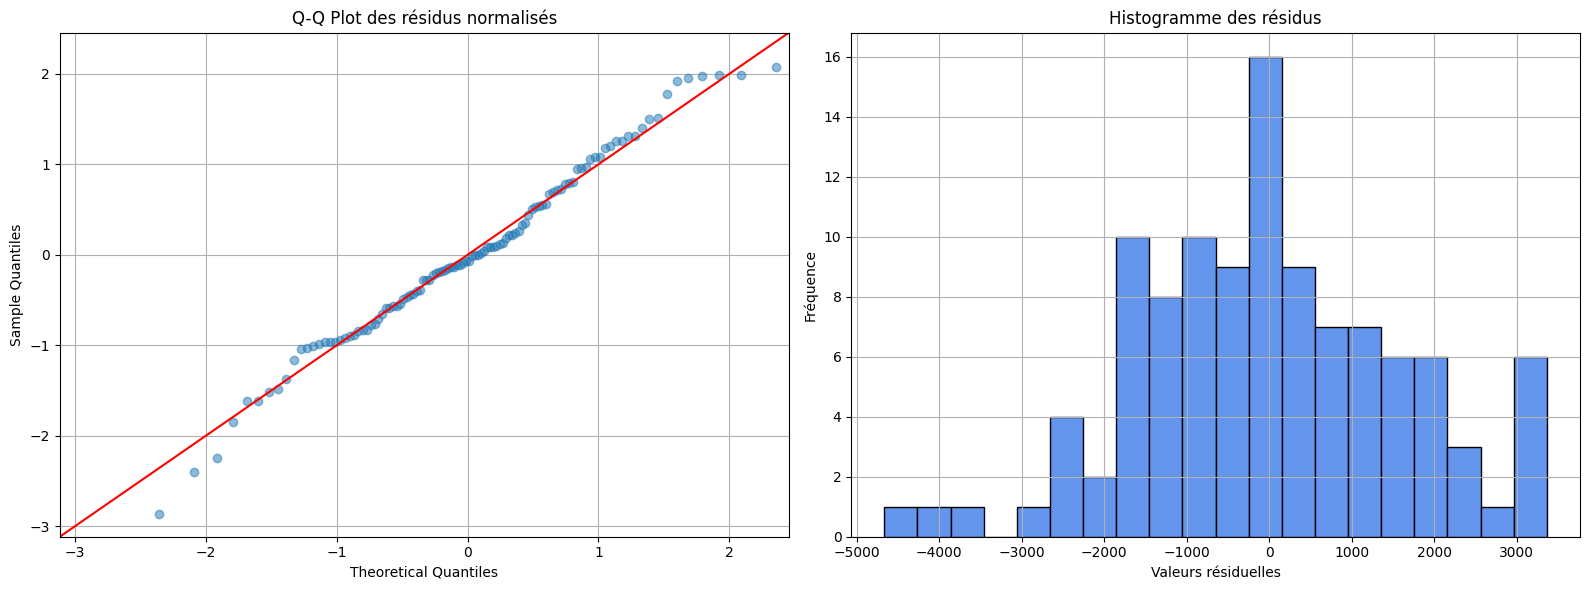

In [45]:
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import ProbPlot

# Récupération des résidus
residus = reg.resid
residus_std = reg.get_influence().resid_studentized_internal

# Création du graphique
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# QQ-Plot des résidus standardisés
qq = ProbPlot(residus_std)
qq.qqplot(line='45', alpha=0.5, color='steelblue', ax=ax[0])
ax[0].set_title('Q-Q Plot des résidus normalisés')
ax[0].grid(True)

# Histogramme des résidus
ax[1].hist(residus, bins=20, color='cornflowerblue', edgecolor='black')
ax[1].set_title('Histogramme des résidus')
ax[1].set_xlabel('Valeurs résiduelles')
ax[1].set_ylabel('Fréquence')
ax[1].grid(True)

# Affichage et sauvegarde
plt.tight_layout()
plt.show()


**Q-Q plot (à gauche)**

* Les points sont globalement alignés sur la droite rouge → les résidus suivent assez bien une loi normale.

* Il y a quelques écarts en queue de distribution (extrêmes légèrement plus importants que prévu par la loi normale).

 **Conclusion** : la normalité est raisonnablement respectée, ce qui valide les résultats du modèle OLS.


 **Histogramme des résidus (à droite)**

* La distribution est centrée autour de zéro.

* Elle est légèrement asymétrique:
  * (légère asymétrie positive) avec
  * un peu plus de résidus élevés (positifs).

* Il y a quelques valeurs extrêmes (> 3000 ou < -4000 GWh), (pas en nombre excessif).

 **Conclusion** : les résidus sont relativement symétriques et à peu près normaux, ce qui est cohérent avec le Q-Q plot.

In [46]:
from scipy.stats import shapiro

In [47]:
shapiro(reg.resid)

ShapiroResult(statistic=np.float64(0.9870404175238878), pvalue=np.float64(0.3843039444515635))

In [48]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Test de Breusch-Pagan sur les résidus du modèle final
bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(
    reg.resid,
    reg.model.exog
)

print("=== Test Breusch–Pagan ===")
print(f"Statistique LM        : {bp_stat:.4f}")
print(f"p-value LM            : {bp_pvalue:.4f}")
print(f"Statistique F         : {f_stat:.4f}")
print(f"p-value F             : {f_pvalue:.4f}")

# Interprétation automatique
alpha = 0.05
if bp_pvalue > alpha:
    print("\n✔ Homoscédasticité respectée (p-value > 0.05).")
    print("   Les résidus ont une variance constante.")
else:
    print("\n⚠ Hétéroscédasticité détectée (p-value ≤ 0.05).")
    print("   La variance des résidus n'est pas constante.")
    print("   → Considérer des corrections : HC0/HC3, log-transformations, etc.")


=== Test Breusch–Pagan ===
Statistique LM        : 0.0286
p-value LM            : 0.8658
Statistique F         : 0.0280
p-value F             : 0.8674

✔ Homoscédasticité respectée (p-value > 0.05).
   Les résidus ont une variance constante.


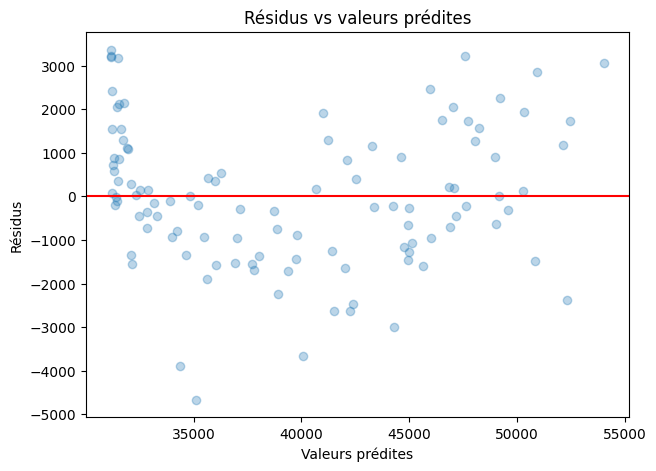

In [49]:
plt.figure(figsize=(7,5))
plt.scatter(reg.fittedvalues, reg.resid, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs valeurs prédites")
plt.show()

Seuil résidus studentisés (±1.98)
Nombre de valeurs influentes : 6 (5.56%)


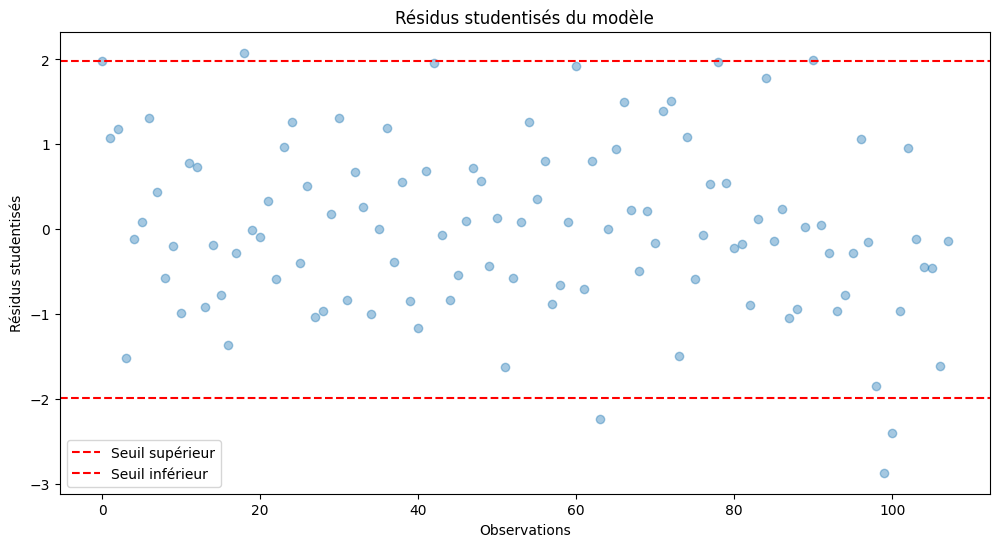

In [50]:
from scipy.stats import t

influence = reg.get_influence()
rstudent = influence.resid_studentized_internal

# Seuil ± t_{α/2, n-p-1}
n = reg.nobs
p = reg.df_model + 1
alpha = 0.05
seuil = t.ppf(1 - alpha/2, n - p - 1)

print(f"Seuil résidus studentisés (±{seuil:.2f})")


outliers = np.sum(np.abs(rstudent) > seuil)
print(f"Nombre de valeurs influentes : {outliers} ({outliers/n*100:.2f}%)")


plt.figure(figsize=(12,6))
plt.scatter(range(len(rstudent)), rstudent, alpha=0.4)
plt.axhline(seuil, color='red', linestyle='--', label='Seuil supérieur')
plt.axhline(-seuil, color='red', linestyle='--', label='Seuil inférieur')
plt.title("Résidus studentisés du modèle")
plt.xlabel("Observations")
plt.ylabel("Résidus studentisés")
plt.legend()
plt.show()

In [51]:
from statsmodels.stats.outliers_influence import OLSInfluence


influence = OLSInfluence(reg)


cooks_d = influence.cooks_distance[0]

n = reg.nobs
p = reg.df_model + 1
seuil_cook = 4 / n


influentes = cooks_d > seuil_cook
print(f"Seuil de Cook : {seuil_cook:.2e}")
print(f"Nombre d'observations influentes : {np.sum(influentes)} / {int(n)}")

Seuil de Cook : 3.70e-02
Nombre d'observations influentes : 10 / 108


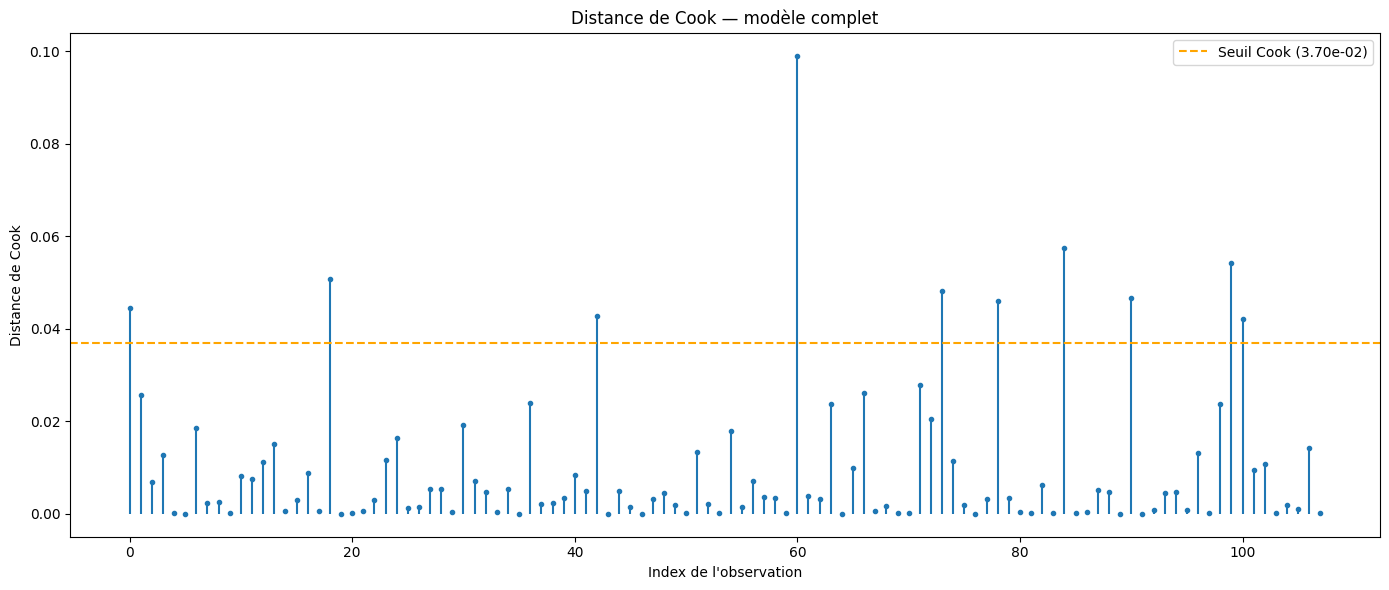

In [52]:
plt.figure(figsize=(14,6))
plt.stem(cooks_d, markerfmt='.', basefmt=" ")
plt.axhline(y=seuil_cook, color='orange', linestyle='--', label=f'Seuil Cook ({seuil_cook:.2e})')
plt.title("Distance de Cook — modèle complet")
plt.xlabel("Index de l'observation")
plt.ylabel("Distance de Cook")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Exemple sur un dataframe X contenant plusieurs variables
[vif for vif in [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]]


[np.float64(2.487469396087751), np.float64(1.0)]

le modèle est :

* Robuste : très bon R² (~0.95)

* Valide statistiquement : les hypothèses du modèle linéaire sont respectées :

  * Linéarité

  * Normalité des résidus

  * Homoscédasticité

  * Indépendance correcte des erreurs (Durbin-Watson ≈ 1.64)

  * Peu affecté par les points influents : la distance de Cook est globalement faible, aucune observation ne dépasse de loin le seuil

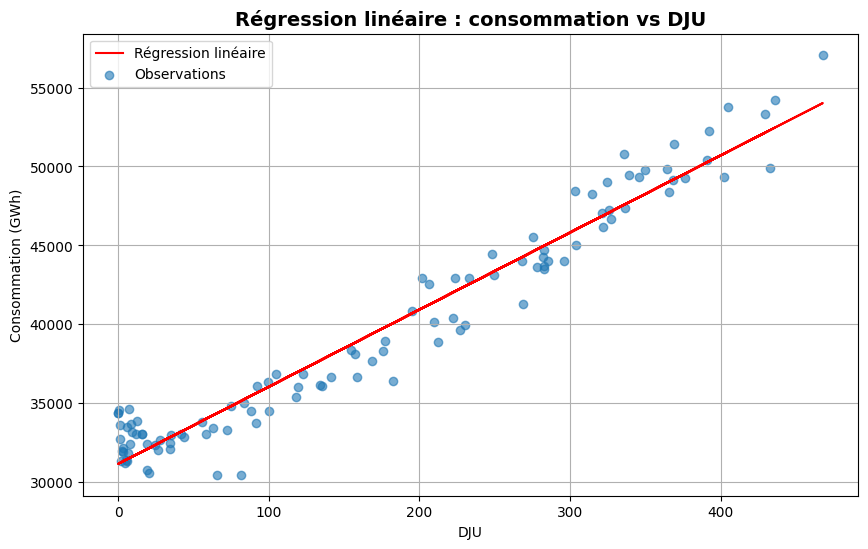

In [54]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os

# Nettoyage préalable (si ce n'est pas déjà fait)
df_merged['dju'] = pd.to_numeric(df_merged['dju'], errors='coerce')
df_merged['conso_GWh'] = pd.to_numeric(df_merged['conso_GWh'], errors='coerce')
df_merged_clean = df_merged.dropna(subset=['dju', 'conso_GWh'])

# Régression avec statsmodels
X = sm.add_constant(df_merged_clean['dju'])
y = df_merged_clean['conso_GWh']
reg = sm.OLS(y, X).fit()

# Tracer les points et la droite de régression
plt.figure(figsize=(10, 6))
plt.plot(df_merged_clean['dju'], reg.predict(X), color='red', label='Régression linéaire')
plt.scatter(df_merged_clean['dju'], df_merged_clean['conso_GWh'], alpha=0.6, label='Observations')

# Titres et axes
plt.title("Régression linéaire : consommation vs DJU", fontsize=14, fontweight='bold')
plt.xlabel("DJU")
plt.ylabel("Consommation (GWh)")
plt.grid(True)
plt.legend()


plt.show()

* La droite rouge représente la régression linéaire estimée :
  * Conso GWh =31160.72 + 48.85 × DJU

* Les points bleus représentent les données mensuelles observées

* Il y a une corrélation très forte et linéaire entre les DJU et la consommation

→ c’est visuellement cohérent avec le R² de 0.947

* Très peu de points s’écartent fortement de la droite

 → bon ajustement global

## Visualisation de la consommation d'éléctricité corrigée



In [55]:
df_clean = df_merged_clean.copy()

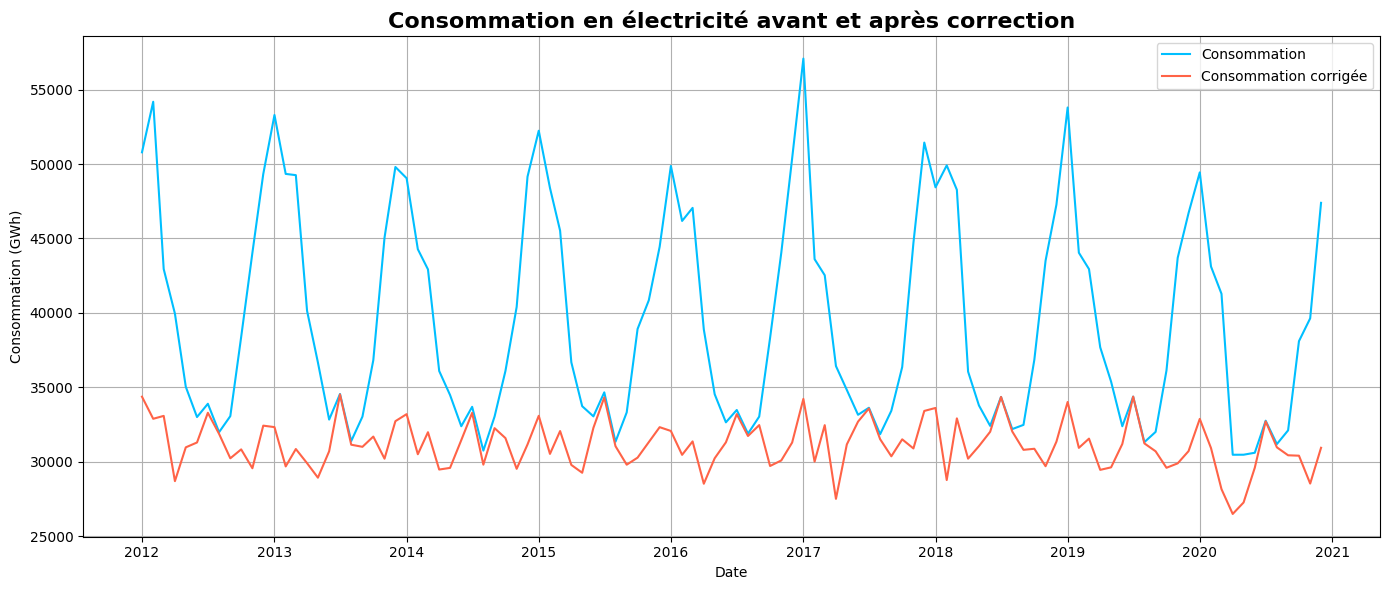

In [56]:
import matplotlib.pyplot as plt

# On suppose que la régression a été faite avec : df_clean, reg = sm.OLS(...).fit()

# 1. Correction de la consommation en retirant l'effet DJU
df_clean['conso_corr'] = df_clean['conso_GWh'] - df_clean['dju'] * reg.params['dju']

# 2. Visualisation : consommation réelle vs corrigée
plt.figure(figsize=(14, 6))
plt.plot(df_clean['date'], df_clean['conso_GWh'], label='Consommation', color='deepskyblue')
plt.plot(df_clean['date'], df_clean['conso_corr'], label='Consommation corrigée', color='tomato')

plt.title('Consommation en électricité avant et après correction', fontsize=16, fontweight='bold')
plt.ylabel("Consommation (GWh)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Amelioration du modèle: Modèle quadratique

In [57]:
df_clean['dju_squared'] = df_clean['dju'] ** 2

X = sm.add_constant(df_clean[['dju', 'dju_squared']])
y = df_clean['conso_GWh']

model_quad = sm.OLS(y, X).fit()
print(model_quad.summary())


                            OLS Regression Results                            
Dep. Variable:              conso_GWh   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     1259.
Date:                Mon, 22 Dec 2025   Prob (F-statistic):           4.17e-74
Time:                        23:07:39   Log-Likelihood:                -936.10
No. Observations:                 108   AIC:                             1878.
Df Residuals:                     105   BIC:                             1886.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3.203e+04    261.843    122.319      

Le modèle quadratique est meilleur que le modèle linéaire simple :

* Meilleur R² (0.960 vs 0.947)

* Résidus plus propres (voir Durbin-Watson ≈ 2)

* Les deux termes (dju et dju²) sont hautement significatifs

-> Cela confirme qu’en hiver rigoureux (DJU élevés), la consommation augmente plus que proportionnellement
 → effet non linéaire du froid.

## Visualisation

                            OLS Regression Results                            
Dep. Variable:              conso_GWh   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     1259.
Date:                Mon, 22 Dec 2025   Prob (F-statistic):           4.17e-74
Time:                        23:07:39   Log-Likelihood:                -936.10
No. Observations:                 108   AIC:                             1878.
Df Residuals:                     105   BIC:                             1886.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3.203e+04    261.843    122.319      

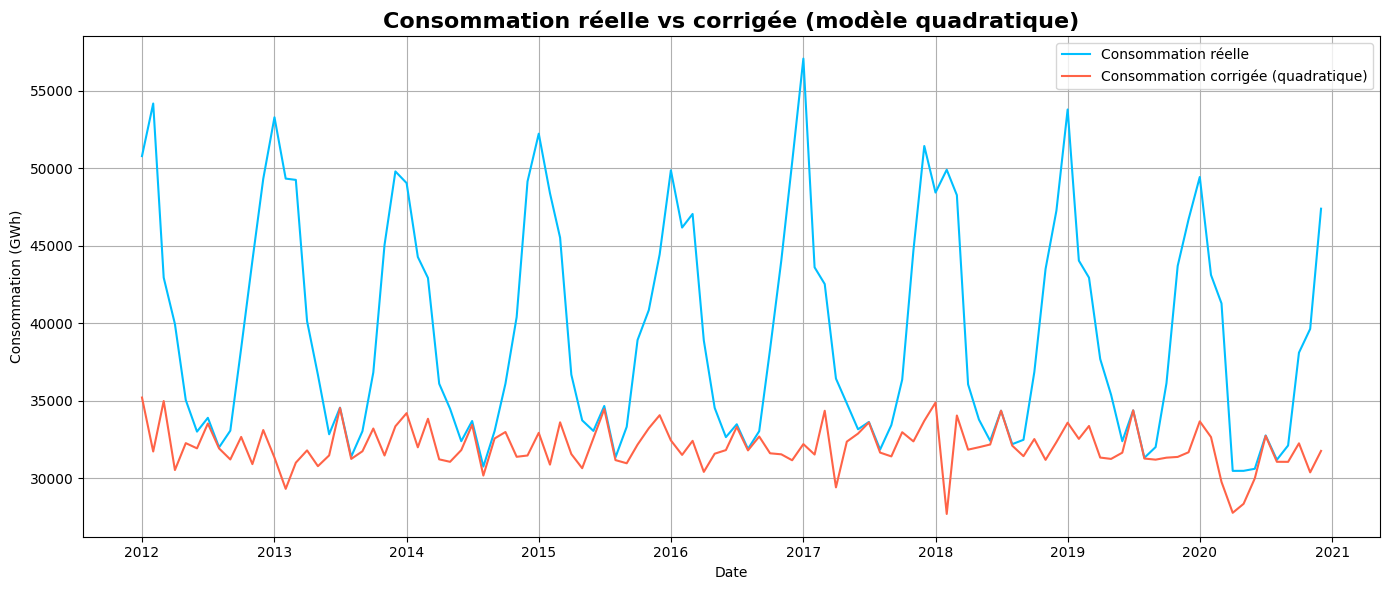

In [58]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Préparation des données (à adapter selon ton fichier)
# Suppose que df_clean contient déjà les colonnes : 'date', 'dju', 'conso_GWh'
df_clean['dju_squared'] = df_clean['dju'] ** 2  # Terme quadratique

# 2. Modèle quadratique : conso = a + b1*dju + b2*dju²
X = sm.add_constant(df_clean[['dju', 'dju_squared']])
y = df_clean['conso_GWh']
model_quad = sm.OLS(y, X).fit()

# 3. Affichage du résumé du modèle (optionnel)
print(model_quad.summary())

# 4. Calcul de la consommation corrigée (on retire l’effet DJU et DJU²)
df_clean['conso_corr_quad'] = df_clean['conso_GWh'] - (
    model_quad.params['dju'] * df_clean['dju'] +
    model_quad.params['dju_squared'] * df_clean['dju_squared']
)

# 5. Visualisation : conso réelle vs corrigée
plt.figure(figsize=(14, 6))
plt.plot(df_clean['date'], df_clean['conso_GWh'], label='Consommation réelle', color='deepskyblue')
plt.plot(df_clean['date'], df_clean['conso_corr_quad'], label='Consommation corrigée (quadratique)', color='tomato')
plt.title("Consommation réelle vs corrigée (modèle quadratique)", fontsize=16, fontweight='bold')
plt.ylabel("Consommation (GWh)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


* **Ligne bleue** : consommation réelle, très saisonnière (pics hivernaux dus au chauffage)

* **Ligne rouge** : consommation corrigée de l'effet non linéaire du chauffage (modèle quadratique)

→ elle est beaucoup plus stable dans le temps, reflétant mieux la tendance structurelle

# Partie 3: Désaisonnalisation de la consommation après correction, grâce aux moyennes mobiles

## Saisonalité moyenne (moyenne par mois de toutes les années)

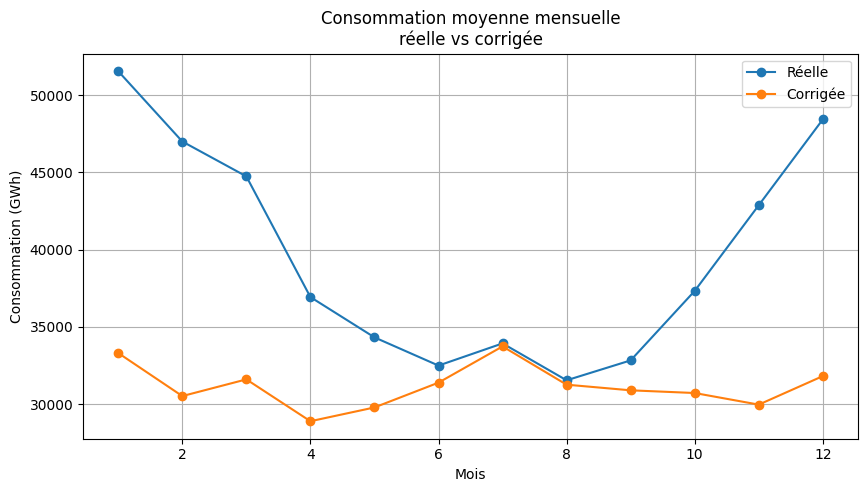

In [59]:
df_clean['mois'] = df_clean['date'].dt.month
moy_mensuelle = df_clean.groupby('mois')[['conso_GWh', 'conso_corr']].mean()

moy_mensuelle.plot(figsize=(10, 5), marker='o')
plt.title("Consommation moyenne mensuelle\nréelle vs corrigée")
plt.xlabel("Mois")
plt.ylabel("Consommation (GWh)")
plt.grid(True)
plt.legend(["Réelle", "Corrigée"])
plt.show()


**Remarque**:
une hausse persistante de la consommation en été (juillet-août), même après correction, cela peut indiquer :

* Usage accru de climatisation (résidentiel, tertiaire…)

* Utilisation de ventilation ou refroidissement industriel

* Comportements liés aux canicules récentes (de + en + fréquentes)

In [60]:
df_clean['mois'] = df_clean['date'].dt.month
df_clean[df_clean['mois'].isin([7, 8])][['date', 'conso_GWh', 'conso_corr']]


,date,conso_GWh,conso_corr
6,2012-07-01,33896.7665,33291.010226
7,2012-08-01,31989.6845,31872.441350
18,2013-07-01,34553.4195,34524.108713
19,2013-08-01,31390.1265,31145.869938
30,2014-07-01,33691.1715,33285.705607
31,2014-08-01,30749.4295,29806.599170
42,2015-07-01,34661.8545,34324.780444
43,2015-08-01,31345.6270,31047.633994
54,2016-07-01,33479.1635,33200.711019
55,2016-08-01,31887.3865,31731.062300


In [61]:
ecart = moy_mensuelle['conso_GWh'] - moy_mensuelle['conso_corr']
print(ecart)


mois
1     18244.336821
2     16480.261649
3     13141.545840
4      8037.126482
5      4537.744134
6      1104.582454
7       194.319665
8       283.880405
9      1937.768727
10     6610.125366
11    12908.687917
12    16617.588116
dtype: float64


In [62]:
part_chauffage = (ecart / moy_mensuelle['conso_GWh']) * 100
print(part_chauffage)



mois
1     35.388228
2     35.060850
3     29.368553
4     21.760971
5     13.219604
6      3.398843
7      0.572642
8      0.899888
9      5.901549
10    17.706163
11    30.104526
12    34.309181
dtype: float64


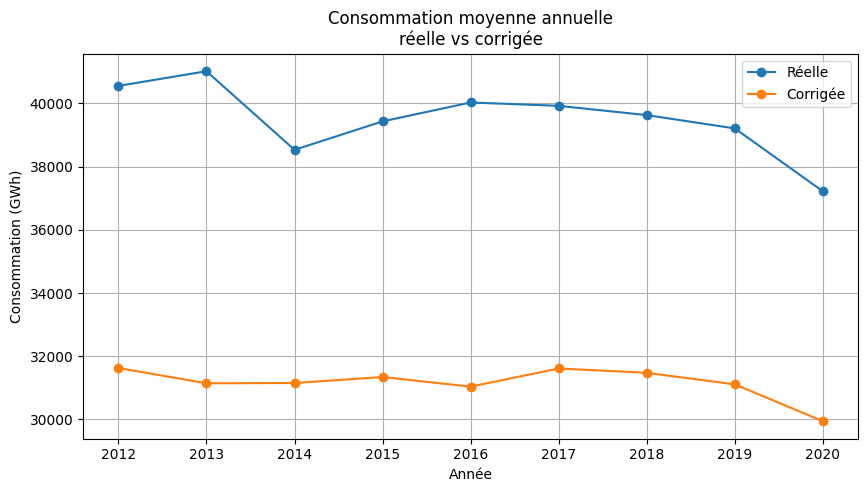

In [63]:
df_clean['annee'] = df_clean['date'].dt.year
moy_annuelle = df_clean.groupby('annee')[['conso_GWh', 'conso_corr']].mean()

moy_annuelle.plot(figsize=(10, 5), marker='o')
plt.title("Consommation moyenne annuelle\nréelle vs corrigée")
plt.xlabel("Année")
plt.ylabel("Consommation (GWh)")
plt.grid(True)
plt.legend(["Réelle", "Corrigée"])
plt.show()


## Décomposition de la série avec seasonal_decompose



doc pour info: https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html

In [64]:
# Création de la colonne consommation corrigée
# Ici on suppose que tu as déjà une régression avec reg.params['dju']
df_merged['conso_corr'] = df_merged['conso_GWh'] - df_merged['dju'] * reg.params['dju']


In [65]:
df_merged.head()

,year,conso_GWh,month_name,dju,date,conso_corr
0,2012,50786.5380,janvier,336.0,2012-01-01,34372.497019
1,2012,54182.0350,février,435.9,2012-02-01,32887.747906
2,2012,42945.5385,mars,201.9,2012-03-01,33082.458518
3,2012,39949.6910,avril,230.3,2012-04-01,28699.233744
4,2012,35038.8335,mai,83.3,2012-05-01,30969.519173


In [66]:
# Utiliser la colonne 'date' comme index
df_merged.set_index('date', inplace=True)
df_merged = df_merged.sort_index()


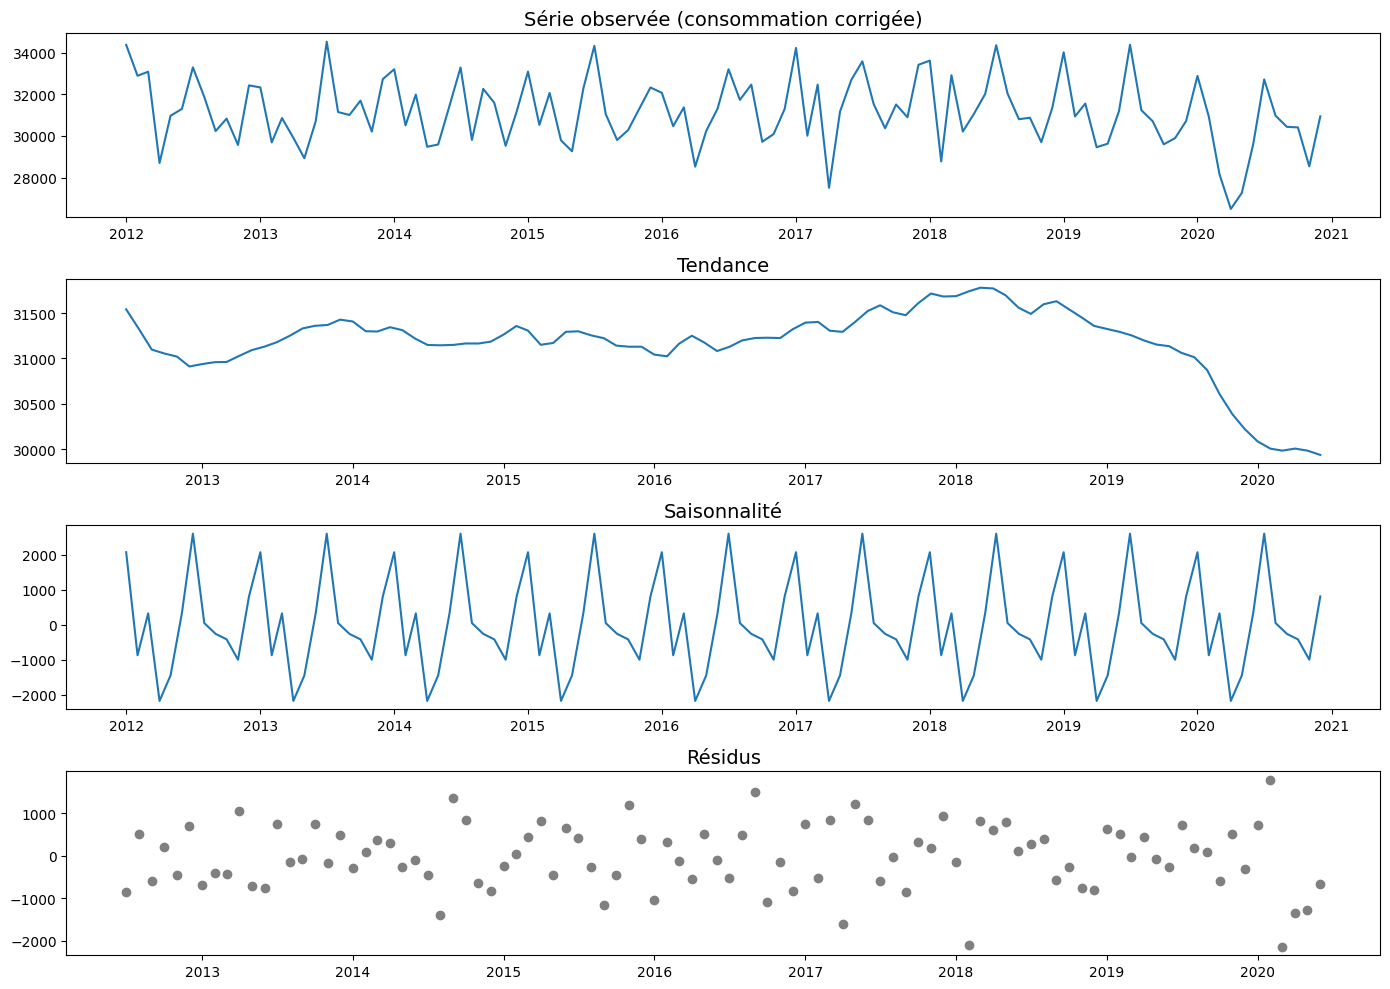

In [67]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Appliquer la décomposition avec une périodicité mensuelle (12 mois)
decomposition = seasonal_decompose(df_merged['conso_corr'], model='additive', period=12)

# Visualisation des composantes
fig, ax = plt.subplots(4, 1, figsize=(14, 10))

ax[0].plot(decomposition.observed)
ax[0].set_title('Série observée (consommation corrigée)', fontsize=14)

ax[1].plot(decomposition.trend)
ax[1].set_title('Tendance', fontsize=14)

ax[2].plot(decomposition.seasonal)
ax[2].set_title('Saisonnalité', fontsize=14)

ax[3].plot(decomposition.resid, 'o', color='grey')
ax[3].set_title('Résidus', fontsize=14)

plt.tight_layout()
plt.show()


* avec tendance linéaire additive (hausse/baisse constante),

* saisonnalité additive (effets saisonniers constants dans l’amplitude, ex. hiver toujours plus élevé, été plus bas),

* sur une série mensuelle avec une saisonnalité annuelle

**La composante « Tendance » montre** :

* * Une évolution lisse et continue, sans rupture brutale.

Une dynamique compatible avec une tendance linéaire locale.

* Une baisse marquée vers 2019–2020, interprétable économiquement (choc exogène: COVID), mais sans explosion de variance.

**Le graphique de saisonnalité est particulièrement instructif** :

* Les cycles annuels sont quasi superposables d’une année sur l’autre.

* L’amplitude saisonnière oscille approximativement entre −2000 et +2500, de façon stable.

* Il n’existe aucune dépendance visible entre le niveau de la série et l’intensité saisonnière.

**Les résidus** :

* Sont centrés autour de zéro.

* Ne présentent pas de structure saisonnière résiduelle visible.

* Ne montrent pas d’hétéroscédasticité flagrante (variance relativement stable).

 Cela indique que :

   * la saisonnalité est correctement captée,

   * le modèle n’est pas sous-spécifié,

  * l’additivité ne laisse pas de structure systématique non expliquée.

### Supression de la saisonalité


La désaisonnalisation permet de mieux observer les évolutions sous-jacentes de la consommation, en supprimant les fluctuations périodiques liées aux saisons.

In [68]:
# Création de la consommation désaisonnalisée
df_merged['conso_cvs'] = df_merged['conso_corr'] - decomposition.seasonal


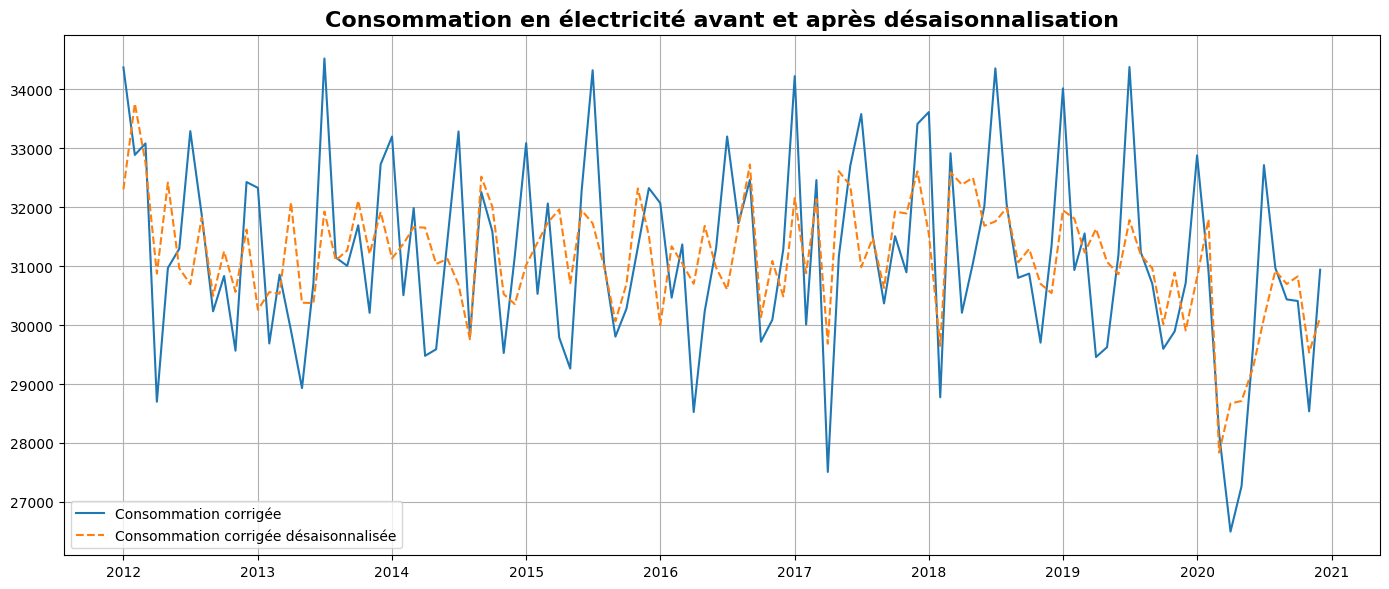

In [69]:
# Tracer consommation corrigée vs désaisonnalisée
plt.figure(figsize=(14, 6))
plt.plot(df_merged['conso_corr'], label='Consommation corrigée')
plt.plot(df_merged['conso_cvs'], label='Consommation corrigée désaisonnalisée', linestyle='--')
plt.title("Consommation en électricité avant et après désaisonnalisation", fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


* La série désaisonnalisée:
  *  conserve le même ordre de grandeur que la série observée.
  * ne présente pas de tendance marquée à la hausse ou à la baisse sur la période observée ➡ relative stationnarité du niveau de consommation corrigé.

* Les écarts saisonniers retirés semblent constants en valeur absolue (quelques milliers d’unités), quelle que soit l’année.

* Il n’y a aucune amplification progressive de la saisonnalité lorsque le niveau augmente.


**Remarque**: C’est un critère fondamental en faveur d’une saisonnalité additive(dans un schéma multiplicatif, l’écart entre les deux courbes augmenterait avec le niveau.)

**Conclusion**

La désaisonnalisation de la consommation d’électricité, après correction de l’effet température, permet d’isoler les effets de fond (tendance) et de mieux comprendre les variations indépendantes du cycle saisonnier.

Malgré la suppression de l’effet climatique (DJU), une saisonnalité significative persiste. Celle-ci peut refléter des usages récurrents comme la climatisation, les comportements estivaux ou les rythmes économiques.

La tendance montre une augmentation progressive jusqu’en 2018, suivie d’une inflexion à la baisse, probablement liée à des changements structurels ou conjoncturels (COVID, politique énergétique, hausse des prix…).

# Partie 3: prévision de la consommation (corrigée de l'effet température) sur un an

## Modèle choisi: (Additive Holt-Winters / Triple Exponential Smoothing)

Conditions du moddèle:

* la série ne présente pas de dynamique multiplicative.
* Amplitude saisonnière stable dans le temps
* Croissance ou décroissance linéaire
* Variance des erreurs indépendante du niveau de saisonnalité


Décomposition du modèle:

* **Tendance : additive** : trend='add'

  * évolution linéaire du niveau de la série dans le temps

   * variations absolues : indépendante du niveau de la série

     (-> constante dans le temps + non proportionelle dans la serie)
                  
  * Exemple implicite : +500 kWh par an, quelle que soit la consommation totale.


* **Saisonnalité : additive** : seasonal='add'
  * La saisonnalité est additive

  * L’amplitude saisonnière est constante dans le temps

  * Les effets saisonniers s’ajoutent au niveau et à la tendance
  * Exemple + kWh en hiver, −kWh en été, quel que soit le niveau global.

* **Périodicité** : seasonal_periods=12
  * La saisonnalité est annuelle sur données mensuelles
  * ->  12 coefficients saisonniers estimés


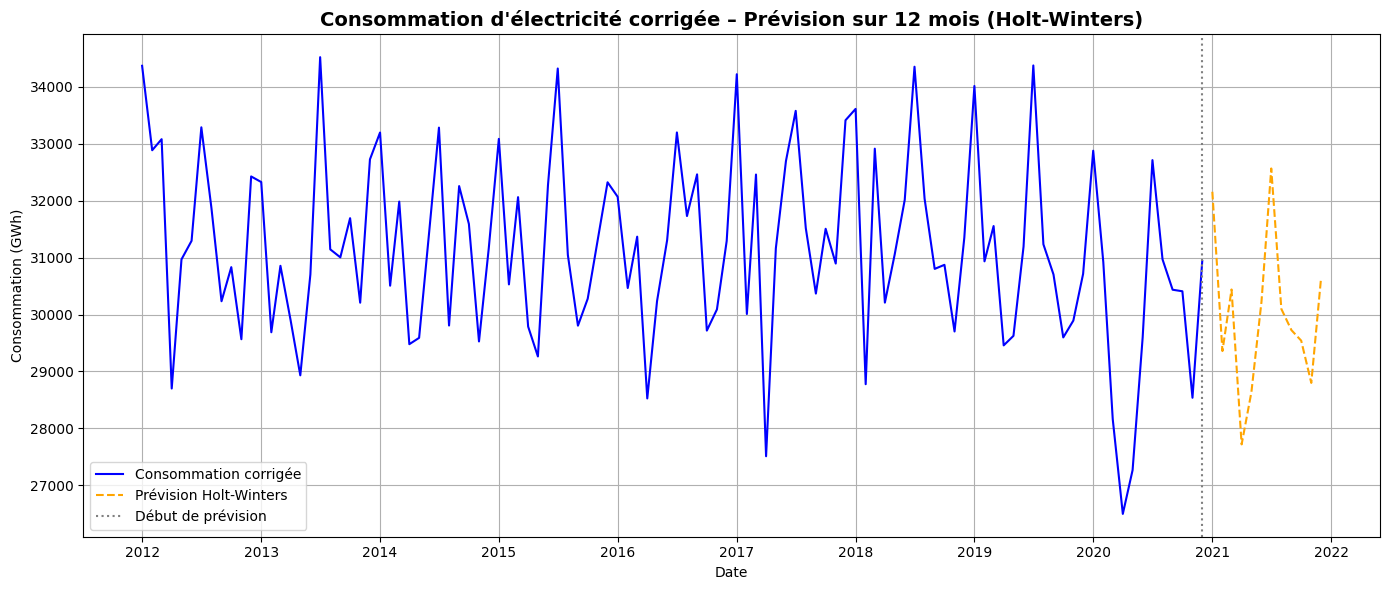

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.api import ExponentialSmoothing
import numpy as np

# Suppose df_corr is ton DataFrame avec l'index en datetime
y = np.asarray(df_merged['conso_corr'])
hw = ExponentialSmoothing(y, seasonal_periods=12, trend='add', seasonal='add').fit()
hw_pred = hw.forecast(12)

# Génération des dates futures pour l'axe x
future_dates = pd.date_range(df_merged.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Création du graphique
plt.figure(figsize=(14,6))
plt.plot(df_merged.index, df_merged["conso_corr"], label='Consommation corrigée', color='blue')
plt.plot(future_dates, hw_pred, label='Prévision Holt-Winters', linestyle='--', color='orange')

# Ligne verticale de séparation
plt.axvline(df_merged.index[-1], color='gray', linestyle=':', label="Début de prévision")

# Ajouts esthétiques
plt.title("Consommation d'électricité corrigée – Prévision sur 12 mois (Holt-Winters)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Consommation (GWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Sauvegarde du graphique si besoin
# plt.savefig("p9_graphic/prevision_hw_améliorée.png")

plt.show()


La série de consommation corrigée présente une tendance faible mais une saisonnalité régulière.

Le modèle Holt-Winters suit correctement la structure de la série historique.

Les prévisions prolongent cette dynamique : on retrouve la même amplitude saisonnière.

Pas d’anticipation de changements brutaux : le modèle est conservateur, ce qui est cohérent avec Holt-Winters additif.

###

In [71]:
from statsmodels.tsa.api import ExponentialSmoothing


df_corr = df_merged.copy()

train = df_corr["conso_corr"][:-12]
test  = df_corr["conso_corr"][-12:]

model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

pred = model.forecast(12)


In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test - pred) / test)) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


MAE : 1333.45
RMSE : 1735.26
MAPE : 4.66%


| Indicateur                            | Valeur          | Interprétation                                                        |
| ------------------------------------- | --------------- | --------------------------------------------------------------------- |
| **MAE** (erreur absolue moyenne)      | **1333.45 GWh** |                      |
| **RMSE** (erreur quadratique moyenne) | **1735.26 GWh** | Plus sensible aux pics extrêmes                                       |
| **MAPE** (erreur en %)                | **4.66%**       | Très bon niveau de précisions |


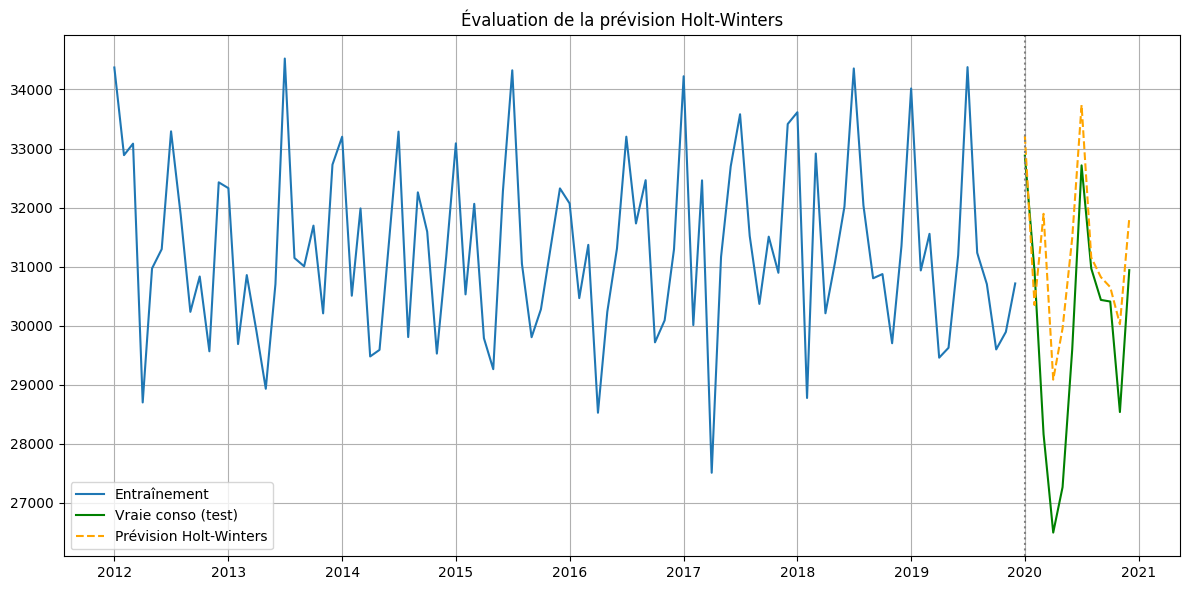

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Entraînement")
plt.plot(test.index, test, label="Vraie conso (test)", color='green')
plt.plot(test.index, pred, label="Prévision Holt-Winters", color='orange', linestyle='--')
plt.axvline(test.index[0], color='grey', linestyle=':')
plt.title("Évaluation de la prévision Holt-Winters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Le modèle a été entraîné sur les données jusqu’en fin 2019, puis testé sur 12 mois réels de 2020.

La prévision suit globalement bien la vraie consommation, même si elle sous-estime légèrement les pics et creux les plus extrêmes:

Observation : La courbe de prévision (pointillée orange) suit partiellement la tendance de la vraie consommation (ligne verte), mais il y a des écarts marqués à certains mois.

Interprétation :

Cela indique que le modèle capte globalement la saisonnalité, mais a des difficultés à prédire avec précision certains points.

C’est courant pour un modèle Holt-Winters si la série a des anomalies ponctuelles, ou un bruit important.

Cela suggère que, sauf événement exceptionnel (politique, sanitaire, économique), la consommation structurelle devrait se maintenir autour des niveaux récents.

## Analyse des residus


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import acf, pacf

def ts_plot(y, lags=None, title='', fig_size=(14,12)):
    """
    Calcul de l'acf, pacf, de l'histogramme et du QQ-plot d'une série temp
    """
    # on transforme en Series si l'argument y n'en est pas une
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    # initialisation de la figure et des axes
    fig = plt.figure(figsize=fig_size)
    ts_ax = fig.add_subplot(311)
    acf_ax = fig.add_subplot(323)
    pacf_ax = fig.add_subplot(324)
    qq_ax = fig.add_subplot(325)
    hist_ax = fig.add_subplot(326)

    # la serie temporelle
    y.plot(ax=ts_ax)
    ts_ax.set_title(title);

    # ACF et PACF
    smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
    smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05, method='ywm')

    # QQ-plot
    sm.qqplot(y, line='s', ax=qq_ax)
    qq_ax.set_title('QQ-Plot')

    # histogramme
    y.plot(ax=hist_ax, kind='hist', bins=25);
    hist_ax.set_title('Histogramme');
    plt.tight_layout();
    plt.show()


def plot_acf_pacf(y, plot_pacf=False, fig_size=(14,6)):
    """
    représentation des sorties ACF/PACF
    """
    label = 'ACF'
    y_len = len(y)
    y2 = acf(y.values, fft=True)

    if plot_pacf:
        y2 = pacf(y.values)[1:]
        label = 'PACF'

    plt.figure(figsize=fig_size)
    plt.bar(range(len(y2)), y2, width = 0.1)
    plt.xlabel('lag')
    plt.ylabel(label)
    plt.axhline(y=0, color='black')
    plt.axhline(y=-1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
    plt.axhline(y=1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
    plt.ylim(-1, 1)
    plt.xlim(0,20)
    plt.show()


def plotseasonal(res, axes ):
    """
    représentation des différentes composantes d'une série
    """
    res.observed.plot(ax=axes[0], legend=False)
    axes[0].set_ylabel('Observed')
    res.trend.plot(ax=axes[1], legend=False)
    axes[1].set_ylabel('Trend')
    res.seasonal.plot(ax=axes[2], legend=False)
    axes[2].set_ylabel('Seasonal')
    res.resid.plot(ax=axes[3], legend=False)
    axes[3].set_ylabel('Residual')

In [75]:
test.index.equals(pred.index)


True

In [77]:
residuals = test - pred

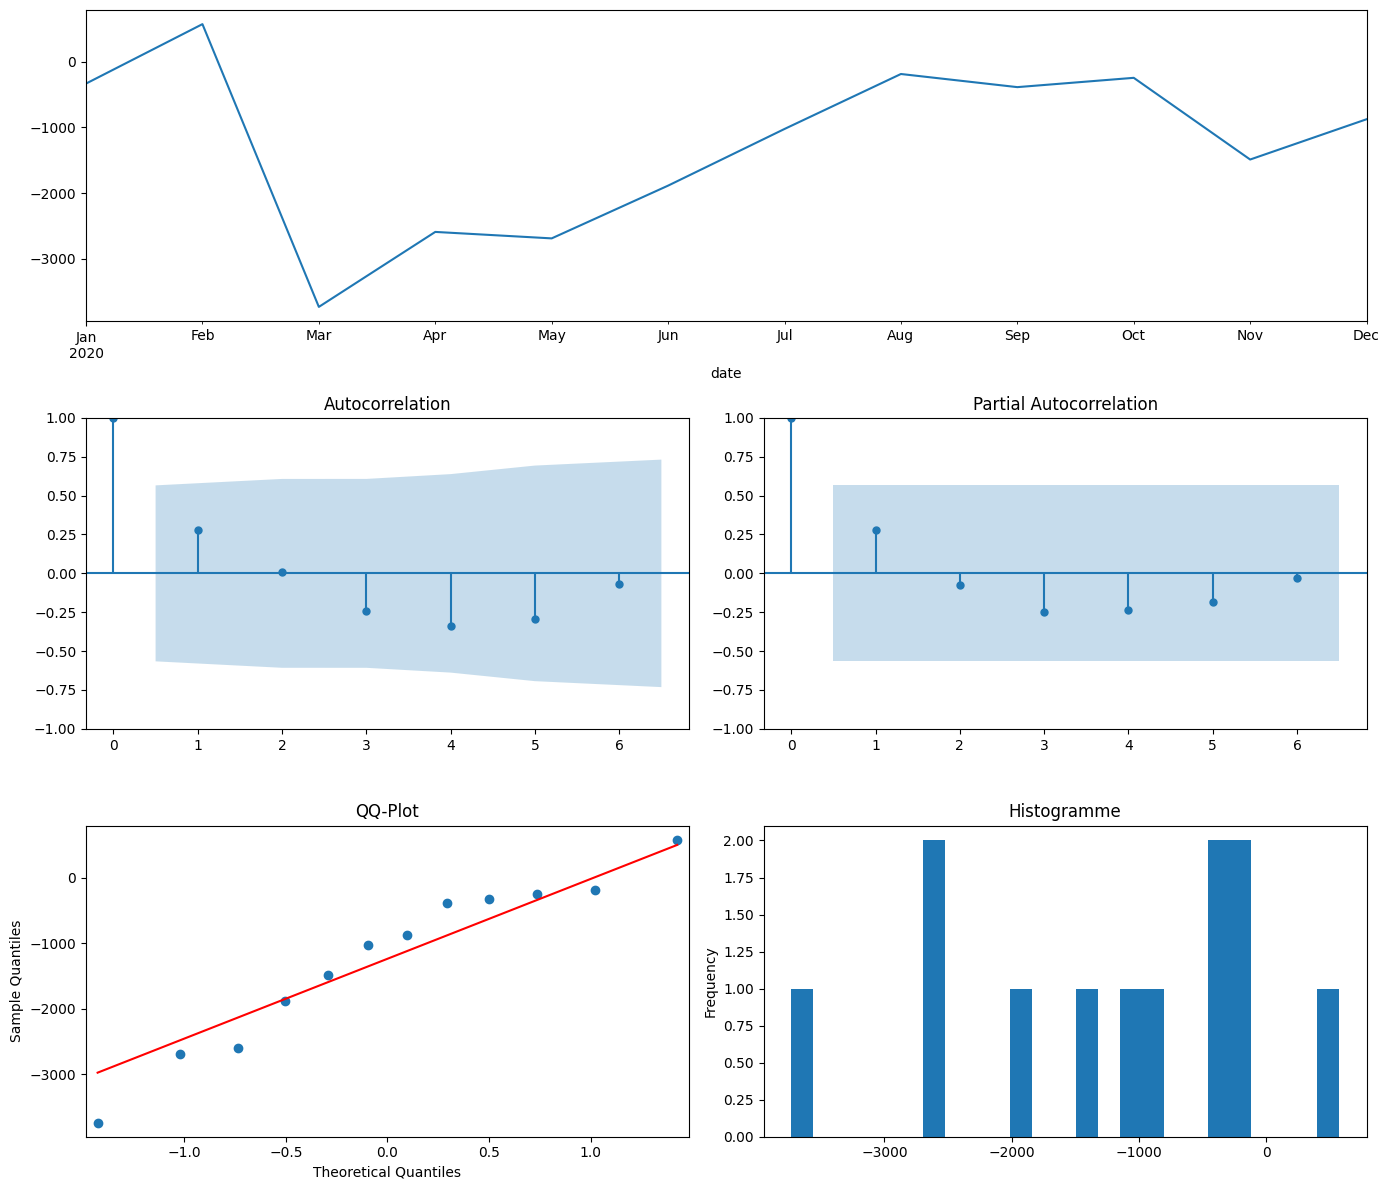

In [78]:
ts_plot(residuals)

**Histogramme des résidus**

Observation : La distribution est asymétrique, légèrement centrée vers la gauche, ce qui indique que les erreurs de prédiction:

Interprétation :

Idéalement, les résidus devraient être centrés autour de 0 et avoir une distribution gaussienne (en cloche).


L’asymétrie suggère que le modèle tend à sous-estimer la consommation dans certaines situations (surtout les pics).

Cela peut refléter :

un effet non capté (ex. événements exceptionnels, pics d’activité)

ou un modèle trop conservateur (lissage trop fort)

**QQ Plot**

Le Q-Q plot montre que les résidus ne suivent pas parfaitement une loi normale.
Une asymétrie est présente, ce qui est cohérent avec l’histogramme des résidus :
le modèle tend à sous-estimer certaines valeurs élevées (résidus négatifs fréquents).

Cela peut suggérer :

Un biais du modèle,

Ou la nécessité de modéliser séparément les pics (hiver, chaleur, etc.).

| Observation                                                              | Interprétation                                                          |
| ------------------------------------------------------------------------ | ----------------------------------------------------------------------- |
| Les points **s'écartent légèrement de la droite** sur les bords (queues) | Il y a des **résidus extrêmes** (valeurs aberrantes ou non gaussiennes) |
| Une **courbure vers le haut ou le bas** en milieu de courbe              | Cela indique une **asymétrie** (skewness) dans les erreurs              |
| Les points sont **globalement proches de la diagonale** au centre        | Les **résidus "normaux" (courants)** sont bien captés                   |


Observation : Seul le premier décalage (lag 1) est significatif (attendu), tous les autres sont dans les bandes de confiance.

Interprétation :

Les résidus ne présentent pas de structure de dépendance dans le temps.

Cela confirme que le modèle respecte l’hypothèse d’indépendance des erreurs.

Aucune information temporelle significative oubliée ne semble subsister.

**Conclusion**

| Critère                        | Évaluation                                           |
| ------------------------------ | ---------------------------------------------------- |
| Qualité de l’ajustement visuel | Moyenne : suit la tendance mais erreurs visibles     |
| Distribution des résidus       | Moyenne à faible : asymétrie présente                |
| Autocorrélation des résidus    | Bonne : peu ou pas de corrélation significative      |
| Prise en compte saisonnalité   | Oui, bien captée                                     |
| Prise en compte tendance       | Oui, mais améliorable                                |
| Prévision fiable à 12 mois     | Moyennement fiable, à tester avec d'autres métriques |


## SARIMA manuel

https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html

https://blog.statoscop.fr/timeseries-3.html

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df_sarima = df_merged.copy()
df_sarima.index = pd.to_datetime(df_sarima.index)
df_sarima = df_sarima.asfreq('MS')
y = df_sarima['conso_corr']


In [ ]:
y_train = y[:-12]
y_test = y[-12:]


Modèle utilisé :

SARIMA(1,1,1)(1,1,1,12) :

order=(1,1,1) → composantes AR, I, MA non saisonnières

seasonal_order=(1,1,1,12) → composantes AR, I, MA saisonnières (annuelles sur données mensuelles)

Cela modélise à la fois la tendance et la saisonnalité annuelle.

In [ ]:
model1 = SARIMAX(y_train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False)

results1 = model1.fit()


In [ ]:
forecast = results1.get_forecast(steps=12)
forecast_moy = forecast.predicted_mean
conf_int = forecast.conf_int()


In [ ]:
mae = mean_absolute_error(y_test, forecast_moy)
rmse = np.sqrt(mean_squared_error(y_test, forecast_moy))
mape = np.mean(np.abs((test - forecast_moy) / test)) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(y, label='Observée')
plt.plot(forecast_moy, label='Prévision SARIMA', color='orange')
plt.fill_between(forecast_moy.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], color='orange', alpha=0.3)

plt.axvline(y_test.index[0], color='grey', linestyle='--', label='Début test')
plt.title("Prévision de la consommation corrigée (SARIMA)")
plt.legend()
plt.show()


* **Ligne bleue — Série observée**

La série corrigée conserve une variabilité importante, malgré la désaisonnalisation partielle.

* **Ligne orange — Prévision SARIMA**

Elle suit assez bien la structure générale, mais avec un lissage visible.

**Les prévisions sont encadrées par une bande de confiance (IC à 95%)** :

Plus large sur les premiers mois → incertitude relativement élevée

Les valeurs observées réelles restent généralement dans l’intervalle, ce qui est un bon signe

**Ligne verticale grise**

Marque le début de la période de test (12 derniers mois de la série)

En mai 2020, le modèle prévoit une consommation de ~32 000 GWh, mais indique que la vraie valeur a 95 % de chances d’être entre ~30 000 et ~34 000 GWh (selon l’intervalle exact).

## SARIMA optimisé

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

# ======================
# 🔹 1. Données
# ======================
y = df_merged['conso_corr'].dropna().copy()
y.index = pd.to_datetime(df_merged.index.dropna())
y = y.asfreq('MS')  # Fréquence mensuelle

itertools : pour générer les combinaisons de paramètres à tester.
https://docs.python.org/3/library/itertools.html

SARIMAX : pour modéliser la série avec un modèle SARIMA (saisonnier).
https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html

acorr_ljungbox : test d'autocorrélation sur les résidus du modèle.
https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html

adfuller : test de Dickey-Fuller pour vérifier la stationnarité.
https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html

In [ ]:
# ======================
# 🔹 2. Test stationnarité (corrigé)
# ======================
adf_result = adfuller(y)
adf_stat = adf_result[0]
adf_pval = adf_result[1]

print(f"ADF Statistic = {adf_stat:.4f} | p-value = {adf_pval:.4f}")
d = 0 if adf_pval < 0.05 else 1
print(f"Utilisation de d = {d}")

In [ ]:




# ======================
# 🔹 3. Paramètres à tester
# ======================
p = q = range(0, 2)
P = Q = range(0, 2)
D = [1]
m = 12  # saisonnalité annuelle

pdq = list(itertools.product(p, [d], q))
seasonal_pdq = list(itertools.product(P, D, Q))

# ======================
# 🔹 4. Recherche automatique
# ======================
results = []

for order in pdq:
    for seasonal in seasonal_pdq:
        seasonal_order = (seasonal[0], seasonal[1], seasonal[2], m)
        try:
            model = SARIMAX(y,
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            fit = model.fit(disp=False)

            resid = fit.resid
            ljung_p = acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].values[0]
            min_pval = fit.pvalues.min()

            # Assouplir un peu pour ne pas tout bloquer
            if fit.aic < 1e5 and ljung_p > 0.01 and min_pval < 0.05:
                results.append({
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aic': fit.aic,
                    'model': fit,
                    'ljung_p': ljung_p,
                    'min_pval': min_pval
                })

        except Exception as e:
            continue  # on ignore les erreurs silencieusement

# ======================
# 🔹 5. Sélection du meilleur modèle
# ======================
if not results:
    raise ValueError(" Aucun modèle SARIMA valide trouvé.")

results_df = pd.DataFrame(results)
best = results_df.sort_values('aic').iloc[0]
print(f" Meilleur modèle : SARIMA{best['order']} x {best['seasonal_order']} - AIC = {best['aic']:.2f}")

# ======================
# 🔹 6. Prévision sur 12 mois
# ======================
best_model = best['model']
forecast = best_model.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# ======================
# 🔹 7. Visualisation
# ======================
plt.figure(figsize=(15,6))
plt.plot(y, label='Observée')
plt.plot(forecast_mean, label='Prévision SARIMA', color='orange')
plt.fill_between(forecast_mean.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='orange', alpha=0.3)
plt.axvline(y.index[-1], color='gray', linestyle='--', label='Début prévision')
plt.title("Prévision SARIMA automatique sur 12 mois")
plt.xlabel("Date")
plt.ylabel("Consommation corrigée (GWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Interprétation du modèle SARIMA(0,1,1)(0,1,1,12)

Composante non saisonnière :

p=0 : pas d’AR (pas d’autocorrélation immédiate significative)

d=1 : on différencie la série pour la rendre stationnaire

q=1 : une composante MA (correction d'erreur aléatoire récente)

Composante saisonnière (sur 12 mois) :

P=0 : pas d’AR saisonnier

D=1 : différenciation saisonnière

Q=1 : une composante MA saisonnière (permet de lisser les erreurs des mois précédents de l’année précédente)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Vraie conso des 12 derniers mois
y_test = y[-12:]

# Prédictions du modèle sur 12 mois
forecast = best_model.get_forecast(12)
y_pred = forecast.predicted_mean

# Calcul des métriques
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAPE = {mape:.2f}%")


In [ ]:
# Conversion en numpy
y_true = y_test.values
y_hat = y_pred.values

# Masque anti-division par zéro
mask = y_true != 0

# MAPE robuste
mape = np.mean(np.abs((y_true[mask] - y_hat[mask]) / y_true[mask])) * 100

print(f"MAPE corrigé = {mape:.2f}%")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 📌 1. Série complète + index temporel
y = df_merged['conso_corr'].dropna()
y.index = pd.to_datetime(df_merged.index.dropna())

# 📌 2. Découper TRAIN / TEST
y_train = y[y.index < '2020-01-01']
y_test = y[(y.index >= '2020-01-01') & (y.index < '2021-01-01')]

# 📌 3. Re-train le meilleur modèle automatique trouvé
# (ici SARIMA(0, 1, 1)(0, 1, 1, 12) d’après ta recherche automatique)
model = SARIMAX(
    y_train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)

# 📌 4. Faire une prévision sur 12 mois
forecast = model_fit.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 📌 5. Comparer graphiquement les courbes sur 2020
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label='Consommation réelle (2020)', color='blue')
plt.plot(forecast_mean.index, forecast_mean, label='Prévision SARIMA (2020)', color='orange', linestyle='--')
plt.fill_between(forecast_mean.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='orange', alpha=0.3)

plt.axvline(y_test.index[0], color='grey', linestyle=':', label='Début prédiction')
plt.title("Validation du modèle SARIMA sur l'année 2020")
plt.xlabel("Date")
plt.ylabel("Consommation corrigée (GWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1. Évaluation du modèle SARIMA :

Le modèle anticipe correctement la tendance saisonnière.

Les erreurs apparaissent principalement pendant les périodes de confinement.

Cela confirme que SARIMA fonctionne bien en conditions normales mais ne prévoit pas les chocs exogènes.

2. Évaluation de l’impact du confinement (effet COVID) :

Les écarts entre prévision et réalité signalent un comportement de consommation anormal, surtout en :

Avril–Mai 2020 (1er confinement) 🏠

Novembre 2020 (2e confinement) 🔒

Ces écarts peuvent être quantifiés (MAE, RMSE) comme estimation indirecte de l’effet COVID.

Cela met en lumière une hausse atypique de la consommation (résidentielle ?) malgré une prévision à la baisse.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Recharger les données
df = df_merged.copy()
df['date'] = pd.to_datetime(df.index)
df.set_index('date', inplace=True)
y = df['conso_corr'].dropna().asfreq('MS')

# Découper les données
y_train_2019 = y[:'2018-12']
y_test_2019 = y['2019-01':'2019-12']

# Entraînement du modèle SARIMA
model_2019 = SARIMAX(
    y_train_2019,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# Prédictions
forecast_2019 = model_2019.get_forecast(steps=12)
pred_2019 = forecast_2019.predicted_mean
conf_int_2019 = forecast_2019.conf_int()

# Calcul des erreurs
non_zero_mask = y_test_2019 != 0
mae_2019 = mean_absolute_error(y_test_2019, pred_2019)
rmse_2019 = np.sqrt(mean_squared_error(y_test_2019, pred_2019))
mape_2019 = np.mean(np.abs((y_test_2019[non_zero_mask] - pred_2019[non_zero_mask]) / y_test_2019[non_zero_mask])) * 100

# Affichage des erreurs
print(f"MAE  = {mae_2019:.2f} GWh")
print(f"RMSE = {rmse_2019:.2f} GWh")
print(f"MAPE = {mape_2019:.2f} %")

# Tracé du graphique
lower = conf_int_2019["lower conso_corr"].astype(float).values
upper = conf_int_2019["upper conso_corr"].astype(float).values
x_dates = pred_2019.index

plt.figure(figsize=(14,6))
plt.plot(y_test_2019.index, y_test_2019.values, label='Consommation réelle (2019)', color='blue')
plt.plot(x_dates, pred_2019.values, label='Prévision SARIMA (2019)', color='orange', linestyle='--')
plt.fill_between(x_dates, lower, upper, color='orange', alpha=0.3)
plt.axvline(x_dates[0], color='grey', linestyle=':', label='Début prédiction')

plt.title("Validation du modèle SARIMA sur l'année 2019")
plt.ylabel("Consommation corrigée (GWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Recharger les données
df = df_merged.copy()
df['date'] = pd.to_datetime(df.index)
df.set_index('date', inplace=True)
y = df['conso_corr'].dropna().asfreq('MS')

# Découper les données
y_train_2019_2 = y[:'2018-12']
y_test_2019_2 = y['2019-01':'2019-12']

# Entraînement du modèle SARIMA
model_2019_2 = SARIMAX(
    y_train_2019,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# Prédictions
forecast_2019_2 = model_2019_2.get_forecast(steps=12)
pred_2019_2 = forecast_2019_2.predicted_mean
conf_int_2019_2 = forecast_2019_2.conf_int()

# Calcul des erreurs
non_zero_mask_2 = y_test_2019 != 0
mae_2019_2 = mean_absolute_error(y_test_2019_2, pred_2019_2)
rmse_2019_2 = np.sqrt(mean_squared_error(y_test_2019_2, pred_2019_2))
mape_2019_2 = np.mean(np.abs((y_test_2019_2[non_zero_mask_2] - pred_2019_2[non_zero_mask_2]) / y_test_2019_2[non_zero_mask_2])) * 100

# Affichage des erreurs
print(f"MAE  = {mae_2019_2:.2f} GWh")
print(f"RMSE = {rmse_2019_2:.2f} GWh")
print(f"MAPE = {mape_2019_2:.2f} %")

# Tracé du graphique
lower_2 = conf_int_2019_2["lower conso_corr"].astype(float).values
upper_2 = conf_int_2019_2["upper conso_corr"].astype(float).values
x_dates_2 = pred_2019_2.index

plt.figure(figsize=(14,6))
plt.plot(y_test_2019_2.index, y_test_2019_2.values, label='Consommation réelle (2019)', color='blue')
plt.plot(x_dates_2, pred_2019_2.values, label='Prévision SARIMA (2019)', color='orange', linestyle='--')
plt.fill_between(x_dates_2, lower_2, upper_2, color='orange', alpha=0.3)
plt.axvline(x_dates[0], color='grey', linestyle=':', label='Début prédiction')

plt.title("Validation du modèle SARIMA sur l'année 2019 (Manuel)")
plt.ylabel("Consommation corrigée (GWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
residuals = best_model.resid


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Éviter la division par 0 pour MAPE
non_zero_mask = y_test_2019 != 0

mae_2019 = mean_absolute_error(y_test_2019, pred_2019)
rmse_2019 = np.sqrt(mean_squared_error(y_test_2019, pred_2019))
mape_2019 = np.mean(np.abs((y_test_2019[non_zero_mask] - pred_2019[non_zero_mask]) / y_test_2019[non_zero_mask])) * 100

print(f"MAE  = {mae_2019:.2f} GWh")
print(f"RMSE = {rmse_2019:.2f} GWh")
print(f"MAPE = {mape_2019:.2f}%")


In [ ]:
best_model.summary()

In [ ]:
import zipfile
from google.colab import files
import os

zip_name = "plots_export.zip"

with zipfile.ZipFile(zip_name, 'w') as archive:
    for f in os.listdir("plots"):
        archive.write(os.path.join("plots", f))

files.download(zip_name)

| Coefficient | Valeur     | Interprétation                                                                    |
| ----------- | ---------- | --------------------------------------------------------------------------------- |
| `ma.L1`     | -0.8621    | Composante bruit (court terme) très significative                                 |
| `ma.S.L12`  | -0.5896    | Composante **moyenne mobile saisonnière** : impact des erreurs à 12 mois (annuel) |
| `sigma2`    | ≈ 1.06e+06 | Variance des résidus (échelle de la série : GWh)                                  |


Tous les coefficients sont très significatifs (P>|z| < 0.05)

| Test                            | Résultat  | Interprétation                                         |
| ------------------------------- | --------- | ------------------------------------------------------ |
| **AIC = 1365.98**               | Assez bas | Bonne performance relative                             |
| **Ljung-Box Q (p=0.85)**        | ✅ OK      | Pas d'autocorrélation des résidus ⇒ modèle bien ajusté |
| **Jarque-Bera (p=0.38)**        | ✅ OK      | Résidus proches d'une distribution normale             |
| **Heteroskedasticité (p=0.35)** | ✅ OK      | Variance des résidus stable                            |


In [ ]:
df_merged.to_csv("/content/drive/MyDrive/Projet_9/df_merged.csv")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Corriger les index si besoin
y_pred = forecast_mean
y_test_aligned = y_test[y_pred.index]

# MAPE : éviter les divisions par 0
non_zero = y_test_aligned != 0
mae = mean_absolute_error(y_test_aligned, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_aligned, y_pred))
mape = np.mean(np.abs((y_test_aligned[non_zero] - y_pred[non_zero]) / y_test_aligned[non_zero])) * 100

print(f"MAE  = {mae:.2f} GWh")
print(f"RMSE = {rmse:.2f} GWh")
print(f"MAPE = {mape:.2f}%")
